In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import TargetEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MaxAbsScaler

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, SVR
from sklearn.cluster import KMeans

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [18]:
df = pd.read_csv("F:\Jupyter Projects\Phitron AL ML\Dataset\Mall_Customers.csv")
df

<>:1: SyntaxWarning: invalid escape sequence '\J'
<>:1: SyntaxWarning: invalid escape sequence '\J'
C:\Users\HP\AppData\Local\Temp\ipykernel_13120\1720528489.py:1: SyntaxWarning: invalid escape sequence '\J'
  df = pd.read_csv("F:\Jupyter Projects\Phitron AL ML\Dataset\Mall_Customers.csv")


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


১. দূরত্ব-ভিত্তিক অ্যালগরিদম (Distance-Based): K-Means ক্লাস্টারিং মূলত ইউক্লিডীয় দূরত্বের (Euclidean Distance) ওপর ভিত্তি করে কাজ করে।

২. ফিচারের আধিপত্য (Feature Dominance): ডেটাসেটে যদি একটি ফিচারের রেঞ্জ অনেক বড় (যেমন: আয় ৫০,০০০-১,০০,০০০) এবং অন্যটির রেঞ্জ ছোট হয় (যেমন: বয়স ২০-৬০), তবে বড় রেঞ্জের ফিচারটি দূরত্বের হিসাবে একক আধিপত্য বিস্তার করে। ফলে ছোট রেঞ্জের ফিচারটি কোনো গুরুত্ব পায় না।

৩. সমান গুরুত্ব নিশ্চিত করা (Equal Weight): ফিচার স্কেলিং করলে সব ফিচারের মান একটি নির্দিষ্ট সীমার মধ্যে চলে আসে। এতে অ্যালগরিদম প্রতিটি ফিচারকে সমান গুরুত্ব দিয়ে সঠিক ক্লাস্টার বা গ্রুপ তৈরি করতে পারে।

In [19]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df.sample(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
115,116,1,19,65,50
146,147,0,48,77,36
65,66,0,18,48,59
49,50,1,31,40,42
112,113,1,38,64,42
179,180,0,35,93,90
182,183,0,46,98,15
124,125,1,23,70,29
52,53,1,31,43,54
152,153,1,44,78,20


In [20]:
df.drop(columns=['CustomerID'], inplace=True)

In [21]:
df.sample(10)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
150,0,43,78,17
90,1,68,59,55
147,1,32,77,74
23,0,31,25,73
48,1,29,40,42
182,0,46,98,15
33,0,18,33,92
58,1,27,46,51
15,0,22,20,79
12,1,58,20,15


Number of clusters: 1, WCSS: 308862.06000000006
Number of clusters: 2, WCSS: 212889.44245524294
Number of clusters: 3, WCSS: 143391.5923603568
Number of clusters: 4, WCSS: 104414.67534220168
Number of clusters: 5, WCSS: 75399.61541401484
Number of clusters: 6, WCSS: 58348.64136331505
Number of clusters: 7, WCSS: 51130.69008126377
Number of clusters: 8, WCSS: 44687.235534005464
Number of clusters: 9, WCSS: 40857.18667502089
Number of clusters: 10, WCSS: 37175.97669994119
Number of clusters: 11, WCSS: 34615.45297332298
Number of clusters: 12, WCSS: 31698.805611055606
Number of clusters: 13, WCSS: 30034.91891520245
Number of clusters: 14, WCSS: 27602.06350373483
Number of clusters: 15, WCSS: 26727.249567546314
Number of clusters: 16, WCSS: 24580.746302596614
Number of clusters: 17, WCSS: 23702.593638959075
Number of clusters: 18, WCSS: 23147.702450327455
Number of clusters: 19, WCSS: 21614.78289700496
Number of clusters: 20, WCSS: 20072.93374484992


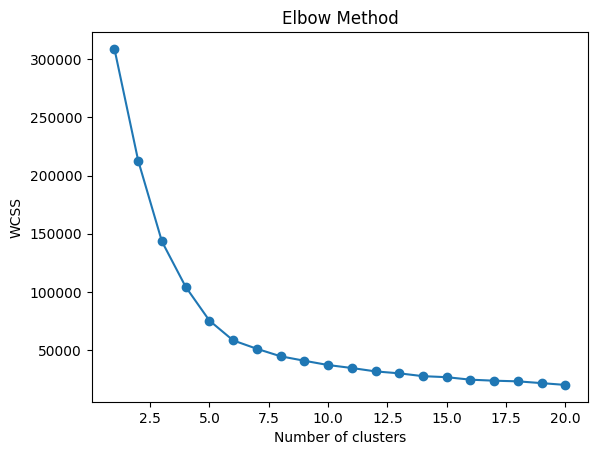

In [22]:
wcss = []
for i in range(1,21):
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(df)
    wcss.append(km.inertia_)

for k, val in zip(range(1,21), wcss):
    print(f"Number of clusters: {k}, WCSS: {val}")

plt.plot(range(1, 21), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [23]:
std_scaler = StandardScaler()
dfS = std_scaler.fit_transform(df)
dfS = pd.DataFrame(dfS, columns=df.columns)

In [24]:
dfS

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,-1.128152,-1.424569,-1.738999,-0.434801
1,-1.128152,-1.281035,-1.738999,1.195704
2,0.886405,-1.352802,-1.700830,-1.715913
3,0.886405,-1.137502,-1.700830,1.040418
4,0.886405,-0.563369,-1.662660,-0.395980
...,...,...,...,...
195,0.886405,-0.276302,2.268791,1.118061
196,0.886405,0.441365,2.497807,-0.861839
197,-1.128152,-0.491602,2.497807,0.923953
198,-1.128152,-0.491602,2.917671,-1.250054


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

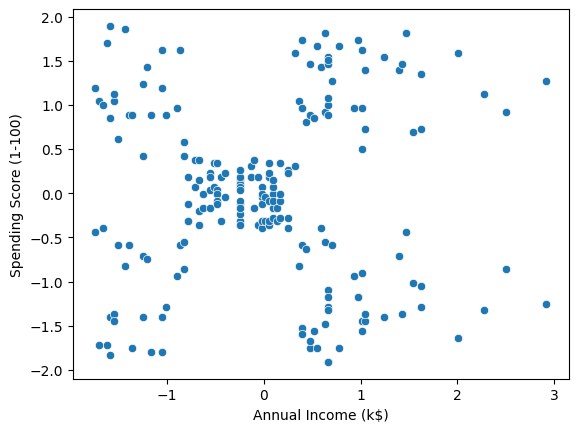

In [25]:
sns.scatterplot(data = dfS, x = 'Annual Income (k$)', y = 'Spending Score (1-100)')

<Axes: xlabel='Age', ylabel='Annual Income (k$)'>

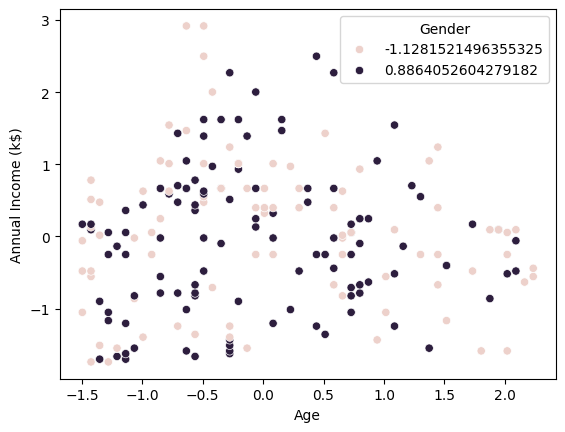

In [26]:
sns.scatterplot(data=dfS, x='Age', y='Annual Income (k$)', hue='Gender')

Number of clusters: 1, WCSS: 800.0
Number of clusters: 2, WCSS: 588.8026767824936
Number of clusters: 3, WCSS: 476.78755441351586
Number of clusters: 4, WCSS: 388.71786140538444
Number of clusters: 5, WCSS: 331.3098837641086
Number of clusters: 6, WCSS: 276.4117595313096
Number of clusters: 7, WCSS: 236.2049470708688
Number of clusters: 8, WCSS: 199.7504611206557
Number of clusters: 9, WCSS: 174.23547730691476
Number of clusters: 10, WCSS: 152.02983429775685
Number of clusters: 11, WCSS: 137.49737186521224
Number of clusters: 12, WCSS: 126.2010079697911
Number of clusters: 13, WCSS: 116.95440603786447
Number of clusters: 14, WCSS: 108.78584626000605
Number of clusters: 15, WCSS: 99.09726022394983
Number of clusters: 16, WCSS: 94.48007280062177
Number of clusters: 17, WCSS: 87.54066798786452
Number of clusters: 18, WCSS: 86.44374178170847
Number of clusters: 19, WCSS: 79.19109516793561
Number of clusters: 20, WCSS: 74.19439176434022


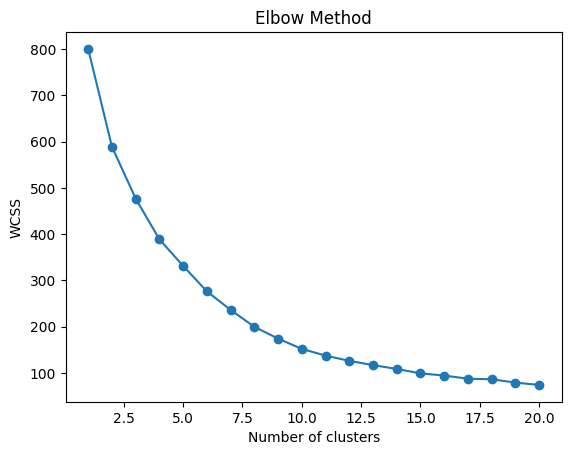

In [27]:
wcss = []
for i in range(1,21):
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(dfS)
    wcss.append(km.inertia_)

for k, val in zip(range(1,21), wcss):
    print(f"Number of clusters: {k}, WCSS: {val}")

plt.plot(range(1, 21), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [28]:
df = pd.read_csv("F:\Jupyter Projects\Phitron AL ML\Dataset\Mall_Customers.csv")
df.drop(columns=['CustomerID'], inplace=True)
df.sample(10)

<>:1: SyntaxWarning: invalid escape sequence '\J'
<>:1: SyntaxWarning: invalid escape sequence '\J'
C:\Users\HP\AppData\Local\Temp\ipykernel_13120\51915451.py:1: SyntaxWarning: invalid escape sequence '\J'
  df = pd.read_csv("F:\Jupyter Projects\Phitron AL ML\Dataset\Mall_Customers.csv")


,Gender,Age,Annual Income (k$),Spending Score (1-100)
189,Female,36,103,85
33,Male,18,33,92
111,Female,19,63,54
16,Female,35,21,35
70,Male,70,49,55
8,Male,64,19,3
54,Female,50,43,45
57,Male,69,44,46
129,Male,38,71,75
67,Female,68,48,48


In [29]:
transformer = ColumnTransformer([
    ('ohe',OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['Gender']),
    ('scaler', StandardScaler(), ['Age', 'Annual Income (k$)', 'Spending Score (1-100)'])
])

pipeline = Pipeline([
    ('transformer', transformer),
    ('kmeans', KMeans(n_clusters=5, random_state=42))
])

param_grid = {
    'kmeans__init': ['k-means++', 'random'],
    'kmeans__n_init': [5, 10, 15, 20],
    'kmeans__max_iter': [100, 200, 300]
}

scorer = lambda estimator, X: -estimator.fit(X).named_steps['kmeans'].inertia_

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scorer,
    cv=[(range(len(df)), range(len(df)))],
    n_jobs=-1,
    verbose=1
)

grid_search.fit(df)
print(grid_search.best_params_)
print(-grid_search.best_score_)

Fitting 1 folds for each of 24 candidates, totalling 24 fits
{'kmeans__init': 'k-means++', 'kmeans__max_iter': 100, 'kmeans__n_init': 5}
264.80801456504304


In [30]:

data = pd.read_csv("F:\Jupyter Projects\Phitron AL ML\Dataset\Mall_Customers.csv")
X = data[["Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

km = KMeans(n_clusters=5, init='k-means++', n_init=5, max_iter=100, random_state=42)
labels = km.fit_predict(X_scaled)

data["Cluster"] = labels

print("Customers per cluster:")
print(data["Cluster"].value_counts().sort_index())

print("\nCluster centers (original scale):")
centers_original = scaler.inverse_transform(km.cluster_centers_)
for i, c in enumerate(centers_original):
    print(f"Cluster {i}: Income={c[0]:.1f}k, Spending Score={c[1]:.1f}")

<>:1: SyntaxWarning: invalid escape sequence '\J'
<>:1: SyntaxWarning: invalid escape sequence '\J'
C:\Users\HP\AppData\Local\Temp\ipykernel_13120\866794190.py:1: SyntaxWarning: invalid escape sequence '\J'
  data = pd.read_csv("F:\Jupyter Projects\Phitron AL ML\Dataset\Mall_Customers.csv")


Customers per cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Cluster centers (original scale):
Cluster 0: Income=55.3k, Spending Score=49.5
Cluster 1: Income=86.5k, Spending Score=82.1
Cluster 2: Income=25.7k, Spending Score=79.4
Cluster 3: Income=88.2k, Spending Score=17.1
Cluster 4: Income=26.3k, Spending Score=20.9


In [33]:
np.bincount(km.labels_)

array([81, 39, 22, 35, 23], dtype=int64)

In [32]:
km.cluster_centers_

array([[-0.20091257, -0.02645617],
       [ 0.99158305,  1.23950275],
       [-1.32954532,  1.13217788],
       [ 1.05500302, -1.28443907],
       [-1.30751869, -1.13696536]])

In [31]:
# KMeans centroid location
centers_original

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])